<a href="https://colab.research.google.com/github/RanaMagdyisaac/Bengaluru-House-Price-Prediction/blob/main/FCNN_House_Pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/bengaluru_house_prices.csv")

display(df.head())


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [2]:
print("Data shape: ", df.shape)
print("-" * 50)
df.info()

Data shape:  (13320, 9)
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
# 1. Drop columns with high missing values or low impact on price prediction
df_clean = df.drop(['area_type', 'society', 'balcony', 'availability'], axis=1)

# 2. Drop rows with missing values in the remaining columns
df_clean = df_clean.dropna()

# 3. Clean 'size' column to extract the integer number of rooms (BHK)
df_clean['bhk'] = df_clean['size'].apply(lambda x: int(x.split(' ')[0]))
df_clean = df_clean.drop('size', axis=1)

# 4. Clean 'total_sqft' column (convert ranges to average, and strings to float)
def convert_sqft_to_num(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

df_clean['total_sqft'] = df_clean['total_sqft'].apply(convert_sqft_to_num)

# Drop any rows that returned None from the function above
df_clean = df_clean.dropna()

outlier_columns = ['total_sqft', 'bhk', 'price']
Q1 = df_clean[outlier_columns].quantile(0.25)
Q3 = df_clean[outlier_columns].quantile(0.75)
IQR = Q3 - Q1
df_clean = df_clean[~((df_clean[outlier_columns] < (Q1 - 1.5 * IQR)) | (df_clean[outlier_columns] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Data shape after cleaning:", df_clean.shape)
display(df_clean.head())

Data shape after cleaning: (11099, 5)


,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2
5,Whitefield,1170.0,2.0,38.00,2


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#  Strip leading/trailing whitespaces from the location column
df_clean.location = df_clean.location.apply(lambda x: str(x).strip())

#  Find locations with 10 or fewer data points
location_stats = df_clean.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_stats_less_than_10 = location_stats[location_stats <= 10]

#  Group these rare locations into a single 'other' category
df_clean.location = df_clean.location.apply(lambda x: 'other' if x in location_stats_less_than_10 else x)


df_clean = pd.get_dummies(df_clean, drop_first=True)

X = df_clean.drop('price', axis=1).values
y = df_clean['price'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print('X_train shape: ', X_train_scaled.shape)
print('X_test shape: ', X_test_scaled.shape)
print('y_train shape: ', y_train.shape)

X_train shape:  (8879, 209)
X_test shape:  (2220, 209)
y_train shape:  (8879,)


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=(X_train_scaled.shape[1],)))
model.add(Dense(256, activation='relu', name='hidden_1'))
model.add(Dense(128, activation='relu', name='hidden_2'))
model.add(Dense(64, activation='relu', name='hidden_3'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='linear', name='output'))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 256)            │        53,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,977 (371.00 KB)

 Trainable params: 94,977 (371.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2718.4906 - mae: 38.3959

255/255 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 1508.9314 - mae: 27.2167 - val_loss: 681.9162 - val_mae: 18.6744 - learning_rate: 0.0010
Epoch 2/100
243/255 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 844.5148 - mae: 20.6344

255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 848.3627 - mae: 20.6390 - val_loss: 644.6532 - val_mae: 17.9025 - learning_rate: 0.0010
Epoch 3/100
252/255 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 800.2973 - mae: 19.9317

255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 824.8408 - mae: 20.1574 - val_loss: 629.5339 - val_mae: 17.3286 - learning_rate: 0.0010
Epoch 4/100
248/255 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 837.3557 - mae: 20.2993

255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 811.4241 - mae: 20.0703 - val_loss: 610.6828 - val_mae: 16.9999 - learning_rate: 0.0010
Epoch 5/100
245/255 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 817.2429 - mae: 19.9241

...

255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 746.3651 - mae: 19.2254 - val_loss: 597.4142 - val_mae: 16.4669 - learning_rate: 0.0010
Epoch 12/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 744.4336 - mae: 19.0532 - val_loss: 632.4708 - val_mae: 16.6252 - learning_rate: 0.0010
Epoch 13/100
236/255 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 730.1165 - mae: 18.5917

255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 743.7458 - mae: 19.0368 - val_loss: 593.5501 - val_mae: 16.6682 - learning_rate: 0.0010
Epoch 14/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 725.1919 - mae: 18.8378 - val_loss: 630.2817 - val_mae: 16.5789 - learning_rate: 0.0010
Epoch 15/100
248/255 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 703.7936 - mae: 18.6309

255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 730.2728 - mae: 18.7511 - val_loss: 587.6146 - val_mae: 16.3520 - learning_rate: 0.0010
Epoch 16/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 729.9296 - mae: 18.7697 - val_loss: 600.3410 - val_mae: 16.6642 - learning_rate: 0.0010
Epoch 17/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 718.2547 - mae: 18.7497 - val_loss: 606.1422 - val_mae: 16.5905 - learning_rate: 0.0010
Epoch 18/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 713.8757 - mae: 18.6385 - val_loss: 642.5363 - val_mae: 16.7012 - learning_rate: 0.0010
Epoch 19/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 714.5760 - mae: 18.6345 - val_loss: 608.1725 - val_mae: 17.0870 - learning_rate: 0.0010
Epoch 20/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 718.0471 - mae: 18.6298 - val_loss: 597.6747 - val_mae: 16.5966 - learning_rate: 0.0010
Epoch 21/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 695.4553 - mae: 18.4100 - val_loss: 596.1998 - val_

255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 702.2788 - mae: 18.3468 - val_loss: 583.9181 - val_mae: 16.6715 - learning_rate: 0.0010
Epoch 26/100
254/255 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 699.9739 - mae: 18.3152

255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 691.7390 - mae: 18.2313 - val_loss: 582.7876 - val_mae: 16.1951 - learning_rate: 0.0010
Epoch 27/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 668.3553 - mae: 17.9930 - val_loss: 605.9657 - val_mae: 16.5534 - learning_rate: 0.0010
Epoch 28/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 693.7567 - mae: 18.1944 - val_loss: 610.0270 - val_mae: 16.6961 - learning_rate: 0.0010
Epoch 29/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 672.0209 - mae: 18.0198 - val_loss: 592.8605 - val_mae: 16.8111 - learning_rate: 0.0010
Epoch 30/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 661.2045 - mae: 17.9814 - val_loss: 594.4036 - val_mae: 16.4018 - learning_rate: 0.0010
Epoch 31/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 683.8884 - mae: 18.0428 - val_loss: 586.8177 - val_mae: 16.1755 - learning_rate: 0.0010
Epoch 32/100
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 671.3959 - mae: 18.0134 - val_loss: 591.4108 - val_

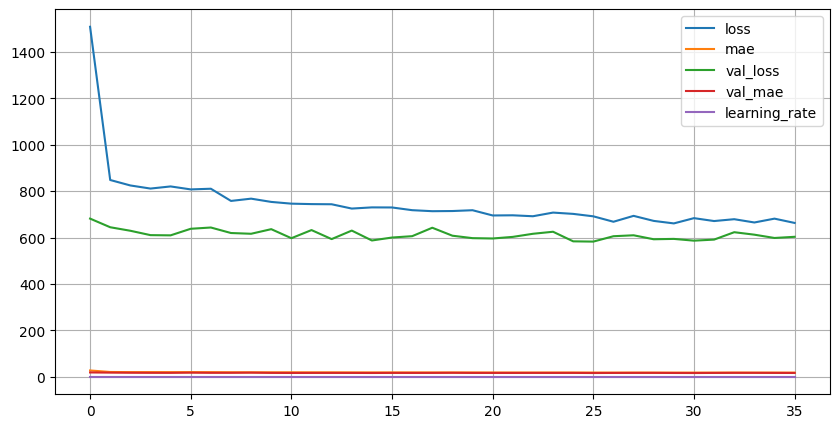

70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 567.2330 - mae: 15.9689


[567.2329711914062, 15.96889591217041]

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import pandas as pd
import matplotlib.pyplot as plt

checkpoint_cb = ModelCheckpoint("my_keras_model.h5", save_best_only=True)
early_stopping_cb = EarlyStopping(patience=10, restore_best_weights=True)
lr_cb = ReduceLROnPlateau(patience=10)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=5/60,
    callbacks=[checkpoint_cb, early_stopping_cb, lr_cb]
)

learning_data = pd.DataFrame(history.history)
learning_data.plot(figsize=(10,5))
plt.grid(True)
plt.show()

model.evaluate(X_test_scaled, y_test)

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_all = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_all)
mse = mean_squared_error(y_test, y_pred_all)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_all)

print("\n" + "="*40)
print("Regression Evaluation Report:")
print("="*40)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

Regression Evaluation Report:
Mean Absolute Error (MAE): 15.97
Root Mean Squared Error (RMSE): 23.82
R-squared (R2 Score): 0.6233


In [12]:
X_new = X_test_scaled[5].reshape(1, -1)
y_pred = model.predict(X_new)

print('Actual Price:', y_test[5])
print('Predicted Price:', y_pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step
Actual Price: 42.3
Predicted Price: 49.23696
